## Configuration

In [1]:
# New York City, New York
# STATE="NY"

# COUNTIES = [
#     "005",  # Bronx
#     "047",  # Brooklyn (Kings County)
#     "061",  # Manhattan
#     "081",  # Queens
#     "085"   # Staten Island (Richmond County)
# ]

# YEAR = 2023

# Denver, Colorado
STATE = "CO"

COUNTIES = [
    "031",  # Denver County
]

YEAR = 2023

# # Tulsa, Oklahoma
# STATE = "OK"

# COUNTIES = [
#     "143",  # Tulsa County
# ]

# YEAR = 2023

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from pathlib import Path

import pygris
from pygris.data import get_lodes
from pygris.utils import erase_water

import r5py

In [3]:
gdf_lodes_blocks = get_lodes(state=STATE, year=2023, lodes_type="wac", cache=True, agg_level="block", return_geometry=True)
gdf_lodes_blocks = gdf_lodes_blocks[gdf_lodes_blocks['w_geocode'].astype(str).str[2:5].isin(COUNTIES)]

# Compute centroids
gdf_lodes_blocks = gdf_lodes_blocks.to_crs(epsg=3857)
gdf_lodes_blocks['centroid'] = gdf_lodes_blocks.geometry.centroid

# Optional: make centroid the active geometry
# lodes_centroids = lodes_data_blocks.set_geometry('centroid')

Requesting feature geometry.
Using FIPS code '08' for input 'co'


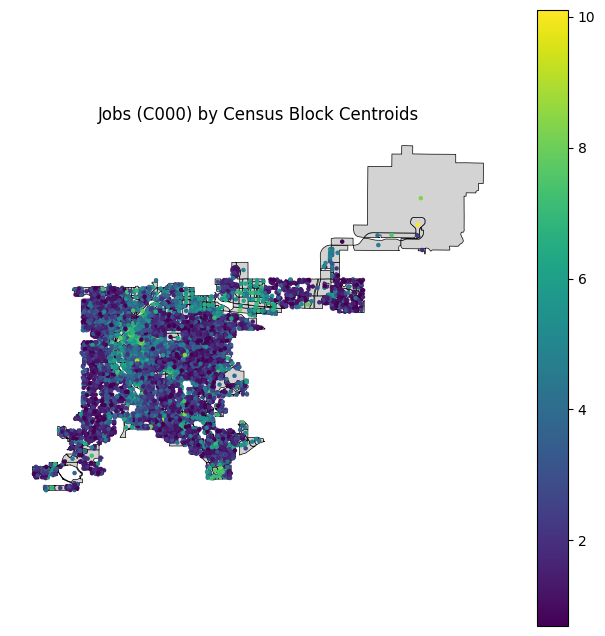

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf_lodes_blocks.plot(
    ax=ax,
    color='lightgray',
    edgecolor='black',
    linewidth=0.5
)

gdf_lodes_blocks.set_geometry("centroid").plot(
    ax=ax,
    column=np.log1p(gdf_lodes_blocks["C000"]),
    markersize=5,
    legend=True
)

ax.set_title("Jobs (C000) by Census Block Centroids")
ax.set_axis_off()

plt.show()

In [5]:
gdf_tracts = pygris.tracts(state=STATE, county=COUNTIES, year=YEAR)
gdf_tracts = erase_water(gdf_tracts)

# gdf_tracts['GEOID'] = gdf_tracts['GEOID'].astype(str)

# Calculate centroids
gdf_tracts = gdf_tracts.to_crs(epsg=3857)
gdf_tracts['centroid'] = gdf_tracts.geometry.centroid

Using FIPS code '08' for input 'CO'


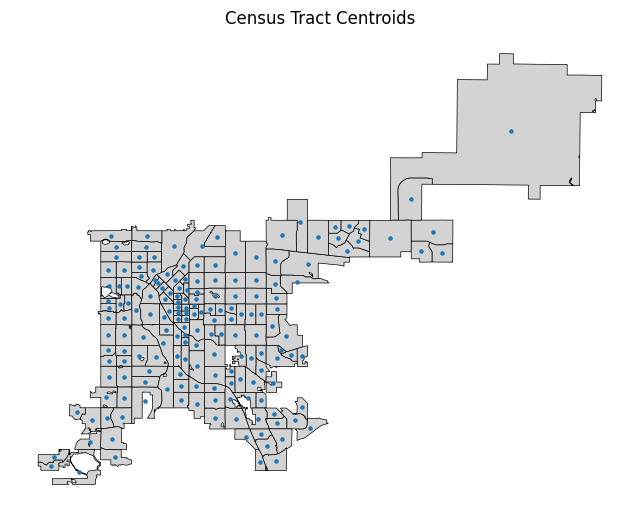

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf_tracts.plot(
    ax=ax,
    color='lightgray',
    edgecolor='black',
    linewidth=0.5
)

gdf_tracts.set_geometry("centroid").plot(
    ax=ax,
    markersize=5,
    legend=True
)

ax.set_title("Census Tract Centroids")
ax.set_axis_off()

plt.show()

In [7]:
transport_network = r5py.TransportNetwork("../data/colorado-260513.osm.pbf",
                                          ["../data/RTD_Denver_Direct_Operated_Commuter_Rail_GTFS.zip", "../data/RTD_Denver_Direct_Operated_Light_Rail_GTFS.zip"]
                                            )

In [8]:
origins = gdf_tracts.copy()
origins.geometry = origins.geometry.centroid

destinations = gdf_lodes_blocks.copy()
destinations.geometry = destinations.geometry.centroid

In [9]:
origins["id"] = origins["GEOID"]
destinations["id"] = destinations["w_geocode"]

In [10]:
travel_time_matrix = r5py.TravelTimeMatrix(
    transport_network,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.BICYCLE, r5py.TransportMode.TRANSIT],
    departure=datetime.datetime(2026, 6, 8, 12, 0, 0),
)

In [11]:
travel_time_matrix.pivot(index="from_id", columns="to_id", values="travel_time")

to_id,080310001021001,080310001021005,080310001021006,080310001021007,080310001021008,080310001021009,080310001021011,080310001021012,080310001021013,080310001021014,...,080319802001015,080319802001016,080319802001017,080319802001018,080319802001020,080319802001021,080319802001022,080319802001026,080319802001031,080319802001033
from_id,,,,,,,,,,,,,,,,,,,,,
08031000102,7.0,5.0,4.0,4.0,3.0,3.0,5.0,5.0,7.0,7.0,...,34.0,35.0,35.0,35.0,33.0,36.0,34.0,38.0,33.0,34.0
08031000201,14.0,12.0,13.0,14.0,15.0,15.0,14.0,13.0,13.0,12.0,...,32.0,33.0,34.0,32.0,30.0,33.0,31.0,35.0,30.0,31.0
08031000202,11.0,8.0,8.0,9.0,10.0,11.0,9.0,9.0,9.0,8.0,...,27.0,29.0,28.0,24.0,22.0,25.0,24.0,27.0,23.0,23.0
08031000301,11.0,8.0,7.0,7.0,7.0,5.0,8.0,8.0,9.0,9.0,...,30.0,31.0,32.0,31.0,29.0,33.0,31.0,34.0,30.0,30.0
08031000302,20.0,16.0,16.0,16.0,15.0,14.0,16.0,16.0,17.0,17.0,...,27.0,29.0,29.0,30.0,28.0,31.0,29.0,32.0,28.0,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
08031015700,80.0,76.0,76.0,76.0,75.0,74.0,76.0,76.0,77.0,76.0,...,59.0,60.0,60.0,63.0,65.0,63.0,64.0,62.0,67.0,68.0
08031015800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
08031980001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
thresholds = [15, 30, 45, 60]

# Add jobs to OD matrix
ttm_jobs = travel_time_matrix.merge(
    gdf_lodes_blocks[['w_geocode', 'C000']],
    left_on='to_id',
    right_on='w_geocode',
    how='left'
)

ttm_jobs['C000'] = ttm_jobs['C000'].fillna(0)

accessibility = pd.DataFrame({
    'from_id': ttm_jobs['from_id'].unique()
})

for threshold in thresholds:
    reachable = ttm_jobs[ttm_jobs['travel_time'] <= threshold]

    jobs = (
        reachable.groupby('from_id')['C000']
        .sum()
        .reset_index(name=f'jobs_{threshold}min')
    )

    accessibility = accessibility.merge(
        jobs,
        on='from_id',
        how='left'
    )

# Replace NaNs with 0
accessibility = accessibility.fillna(0)

In [13]:
# Create readable identifiers
county_str = "-".join(COUNTIES)
threshold_str = "-".join(map(str, thresholds))

# File name
filename = (
    f"accessibility_"
    f"state-{STATE}_"
    f"counties-{county_str}_"
    f"year-{YEAR}_"
    f"thresholds-{threshold_str}.parquet"
)

# Output folder
output_dir = Path("../data/processed_job_accessibility")
output_dir.mkdir(parents=True, exist_ok=True)

# Full path
filepath = output_dir / filename

# Save
accessibility.to_parquet(filepath, index=False)

print(filepath)

../data/processed_job_accessibility/accessibility_state-CO_counties-031_year-2023_thresholds-15-30-45-60.parquet


In [14]:
threshold_cols = [
    "jobs_15min",
    "jobs_30min",
    "jobs_45min",
    "jobs_60min",
]

# Merge accessibility back to tract geometries
gdf_plot = gdf_tracts.merge(
    accessibility,
    left_on="GEOID",
    right_on="from_id",
    how="left"
)

gdf_plot[threshold_cols] = gdf_plot[threshold_cols].fillna(0)

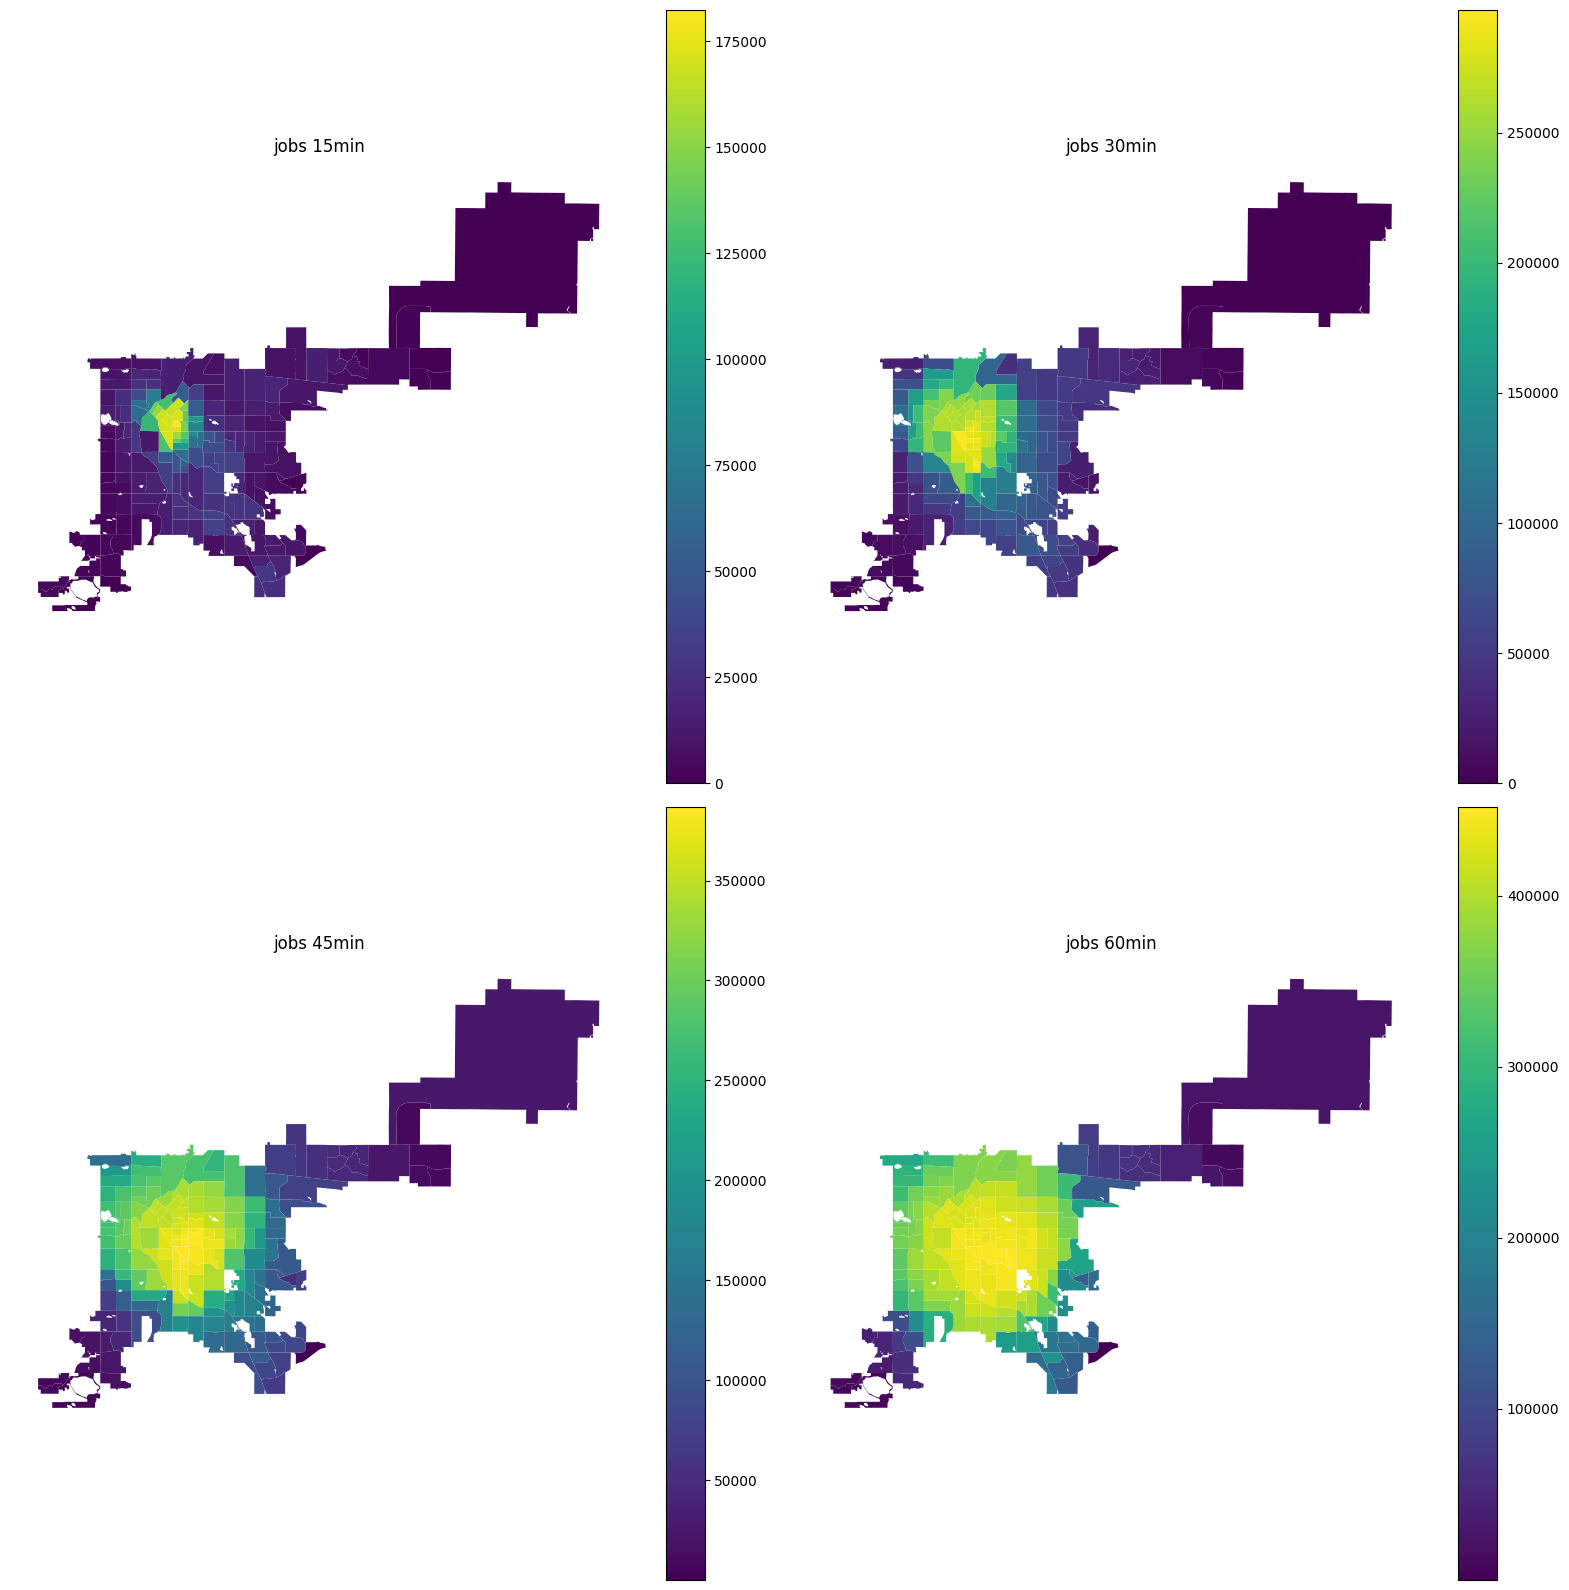

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

axes = axes.flatten()

for ax, col in zip(axes, threshold_cols):
    gdf_plot.plot(
        column=col,
        # scheme="quantiles",
        k=5,
        legend=True,
        ax=ax,
    )

    ax.set_title(col.replace("_", " "))
    ax.set_axis_off()

plt.tight_layout()
plt.show()